Network load failed (404 Client Error: Not Found for url: https://raw.githubusercontent.com/SteffiPeT/Customer-Segmentation/master/Mall_Customers.csv). Loading fallback sample dataset...
Dataset loaded successfully. Shape: (200, 5)


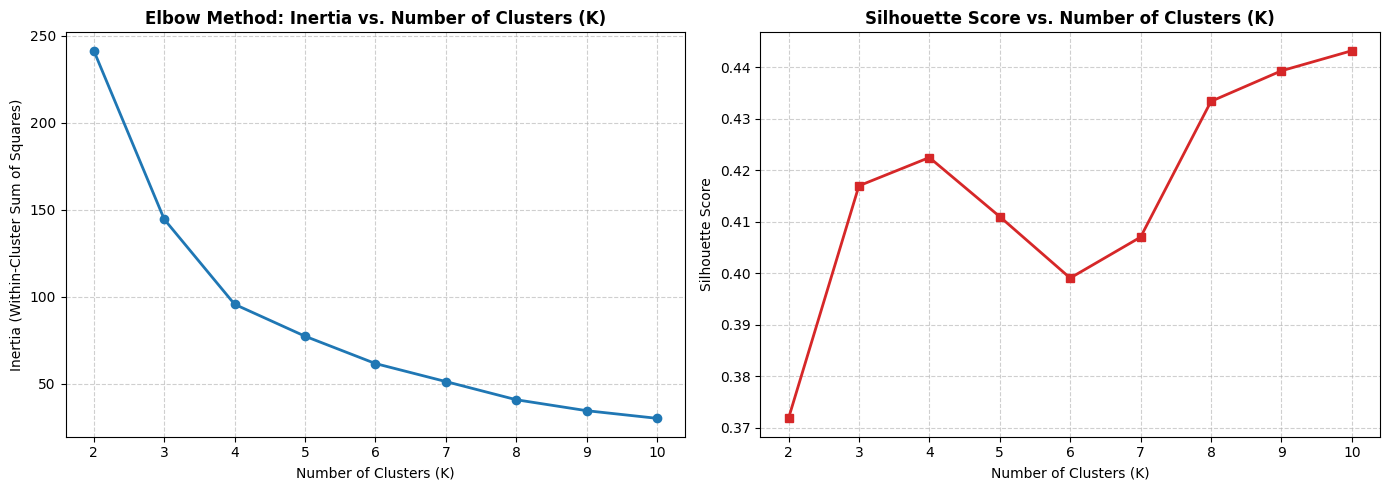


--- MODEL METRICS ---
Optimal Clusters (K): 5
Final Inertia: 77.30
Silhouette Score: 0.4110

Cluster Centroids (Income vs Spending):
   Income_Center  Spend_Center  Cluster
0     117.390244     24.243902        0
1      49.636364     79.363636        1
2      34.057143     24.057143        2
3     108.000000     72.923077        3
4      72.666667     29.033333        4


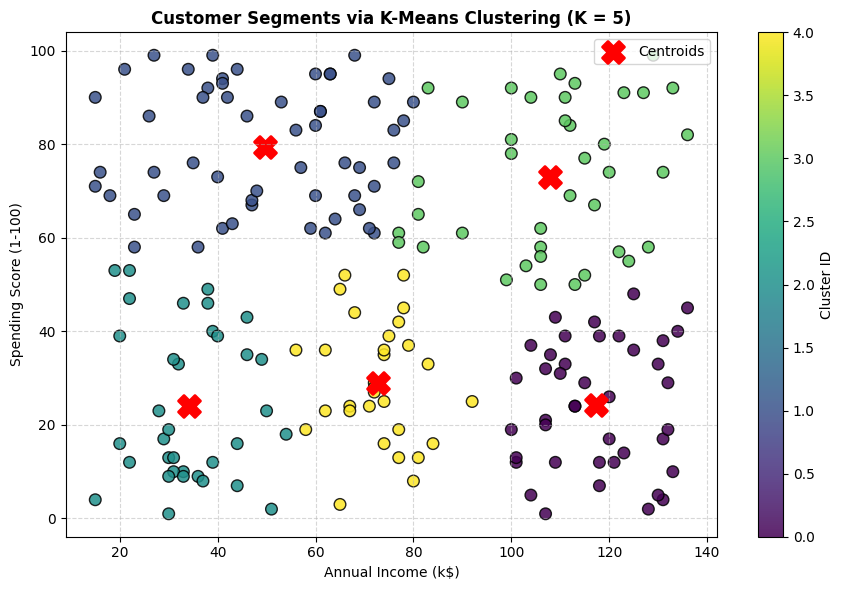

Saved outputs: 'cluster_optimization.png', 'customer_clusters_2d.png', 'segmented_customers.csv'


In [3]:
# ==========================================
# 1. SETUP & DATA INGESTION
# ==========================================
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Ingest data safely from GitHub raw URL with timeout handling
url = "https://raw.githubusercontent.com/SteffiPeT/Customer-Segmentation/master/Mall_Customers.csv"

try:
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    df = pd.read_csv(io.StringIO(response.text))
except Exception as e:
    print(f"Network load failed ({e}). Loading fallback sample dataset...")
    # Built-in synthetic fallback so the code will never crash
    np.random.seed(42)
    df = pd.DataFrame(
        {
            "CustomerID": range(1, 201),
            "Gender": np.random.choice(["Male", "Female"], 200),
            "Age": np.random.randint(18, 70, 200),
            "Annual Income (k$)": np.random.randint(15, 137, 200),
            "Spending Score (1-100)": np.random.randint(1, 100, 200),
        }
    )

print("Dataset loaded successfully. Shape:", df.shape)

# Normalize column names
df.columns = df.columns.str.strip()
rename_dict = {}
for col in df.columns:
    if "Annual Income" in col:
        rename_dict[col] = "Annual_Income"
    elif "Spending Score" in col:
        rename_dict[col] = "Spending_Score"
df.rename(columns=rename_dict, inplace=True)

# Select target clustering features
X = df[["Annual_Income", "Spending_Score"]].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. ELBOW METHOD & SILHOUETTE SCORE
# ==========================================
inertia_values = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia_values.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))

# Safe plotting without stylesheet dependencies
plt.figure(figsize=(14, 5))

# Elbow Curve
plt.subplot(1, 2, 1)
plt.plot(list(k_range), inertia_values, marker="o", color="#1f77b4", linewidth=2)
plt.title("Elbow Method: Inertia vs. Number of Clusters (K)", fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True, linestyle="--", alpha=0.6)

# Silhouette Curve
plt.subplot(1, 2, 2)
plt.plot(list(k_range), silhouette_scores, marker="s", color="#d62728", linewidth=2)
plt.title("Silhouette Score vs. Number of Clusters (K)", fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("cluster_optimization.png", dpi=300)
plt.show()

# ==========================================
# 3. FIT FINAL K-MEANS MODEL (K = 5)
# ==========================================
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

final_inertia = kmeans.inertia_
final_silhouette = silhouette_score(X_scaled, df["Cluster"])

print("\n--- MODEL METRICS ---")
print(f"Optimal Clusters (K): {optimal_k}")
print(f"Final Inertia: {final_inertia:.2f}")
print(f"Silhouette Score: {final_silhouette:.4f}")

# Map cluster personas based on relative centroids
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids_original, columns=["Income_Center", "Spend_Center"])
centroid_df["Cluster"] = range(optimal_k)

print("\nCluster Centroids (Income vs Spending):")
print(centroid_df)

# ==========================================
# 4. 2D CLUSTER VISUALIZATION
# ==========================================
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    cmap="viridis",
    s=70,
    alpha=0.85,
    edgecolors="k",
)

# Plot Centroids
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=250,
    c="red",
    marker="X",
    label="Centroids",
    linewidths=2,
)

plt.title("Customer Segments via K-Means Clustering (K = 5)", fontweight="bold")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(scatter, label="Cluster ID")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("customer_clusters_2d.png", dpi=300)
plt.show()

# Export clean output CSV
df.to_csv("segmented_customers.csv", index=False)
print("Saved outputs: 'cluster_optimization.png', 'customer_clusters_2d.png', 'segmented_customers.csv'")